# 07. Conclusions and Business Recommendations

This notebook summarizes the complete healthcare analytics workflow developed for predicting 30-day hospital readmissions using the UCI Diabetes 130-US Hospitals dataset.

The project included:

- Data understanding
- Data preprocessing
- Baseline model development
- Feature importance analysis
- Model comparison
- Threshold tuning
- Risk stratification

The objective was to identify patients at elevated risk of readmission within 30 days and explore how predictive analytics could support healthcare decision-making.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Project Overview

Hospital readmissions are an important healthcare quality and cost metric. Patients who are readmitted shortly after discharge may require additional clinical support, follow-up care, or care coordination.

The goal of this project was to build a machine learning pipeline capable of predicting whether a patient would be readmitted within 30 days of discharge.

The project used the UCI Diabetes 130-US Hospitals dataset and followed a complete end-to-end healthcare analytics workflow, including data preparation, predictive modeling, model interpretation, threshold tuning, and business-focused recommendations.

## Dataset Summary

The project used the UCI Diabetes 130-US Hospitals dataset, which contains information about patient encounters from multiple hospitals across the United States.

Key characteristics:

- Total encounters: 101,766
- Original features: 50
- Target variable: 30-day readmission
- Positive class rate: approximately 11.2%
- Classification type: binary classification
- Challenge: class imbalance

In [2]:
dataset_summary = pd.DataFrame({
    "Metric": [
        "Total Encounters",
        "Original Features",
        "Target Variable",
        "Positive Class Rate"
    ],
    "Value": [
        "101,766",
        "50",
        "readmitted_30_days",
        "11.2%"
    ]
})

dataset_summary

,Metric,Value
0,Total Encounters,"101,766"
1,Original Features,50
2,Target Variable,readmitted_30_days
3,Positive Class Rate,11.2%


## Methodology Overview

The project followed a structured healthcare analytics workflow.

### Data Understanding
- Explored dataset structure
- Investigated missing values
- Examined target distribution

### Data Preprocessing
- Removed high-missing columns
- Grouped medical specialties
- Created binary target variable
- Handled remaining missing values

### Baseline Modeling
- Built Logistic Regression model
- Established initial benchmark

### Model Interpretation
- Examined feature importance
- Generated patient risk scores
- Investigated key readmission drivers

### Model Comparison
- Compared Logistic Regression
- Compared Random Forest
- Compared Gradient Boosting

### Threshold Tuning
- Evaluated multiple classification thresholds
- Investigated precision-recall tradeoffs
- Developed healthcare-focused recommendations

## Model Comparison Results

Three machine learning models were evaluated using the same train-test split and preprocessing pipeline.

Because this is an imbalanced healthcare classification problem, recall and ROC-AUC were considered particularly important.

In [3]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.6608,
        0.6503,
        0.8886
    ],
    "Precision": [
        0.1800,
        0.1820,
        0.5833
    ],
    "Recall": [
        0.5738,
        0.6085,
        0.0061
    ],
    "F1-score": [
        0.2740,
        0.2800,
        0.0121
    ],
    "ROC-AUC": [
        0.6708,
        0.6809,
        0.6780
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6608,0.1800,0.5738,0.2740,0.6708
1,Random Forest,0.6503,0.1820,0.6085,0.2800,0.6809
2,Gradient Boosting,0.8886,0.5833,0.0061,0.0121,0.6780


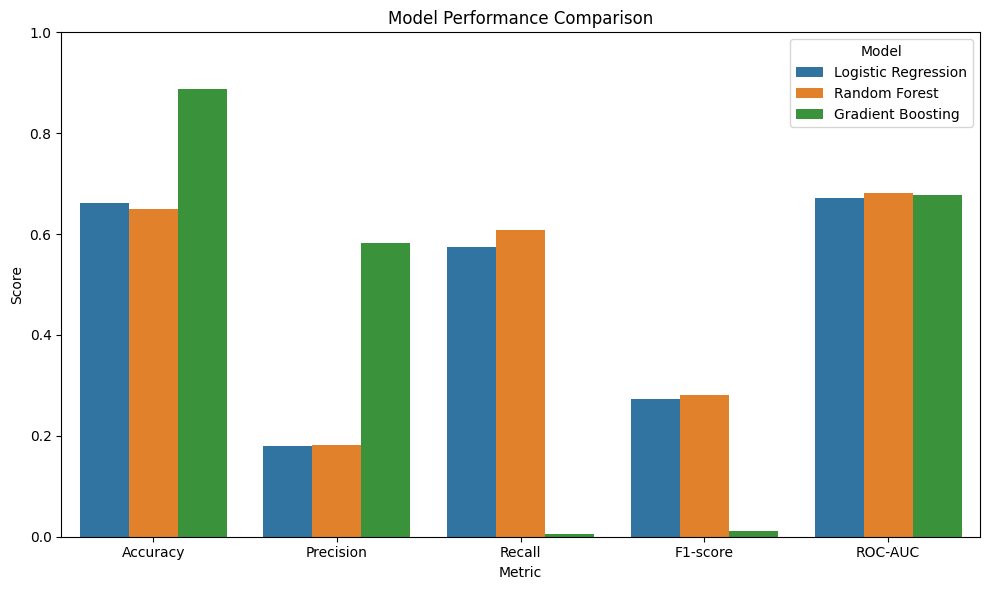

In [4]:
results_melted = model_results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Model Performance Comparison")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

## Best Model Selection

Although Gradient Boosting achieved the highest overall accuracy, it identified very few actual readmission cases and therefore produced extremely low recall.

Because the dataset is imbalanced, accuracy alone is not sufficient for model selection.

Random Forest achieved:

- Highest ROC-AUC
- Highest recall
- Strongest F1-score

Therefore, Random Forest was selected as the final model for subsequent threshold tuning and risk stratification analysis.

## Key Predictors of Readmission

Feature importance analysis highlighted several factors associated with increased readmission risk.

Important utilization-related predictors included:

- Prior inpatient visits
- Emergency department visits
- Number of diagnoses
- Number of medications
- Hospital utilization history

These variables likely reflect patient complexity and healthcare utilization patterns.

The results suggest that patients with extensive prior healthcare utilization may require additional discharge support and follow-up care.

## Threshold Tuning Findings

Threshold tuning demonstrated that model performance can change substantially depending on the selected classification threshold.

The default threshold of 0.50 was compared with a lower threshold of 0.45.

In [5]:
threshold_comparison = pd.DataFrame({
    "Setting": [
        "Default Threshold",
        "Recommended Threshold"
    ],
    "Threshold": [
        0.50,
        0.45
    ],
    "Recall": [
        0.6085,
        0.9114
    ]
})

threshold_comparison

,Setting,Threshold,Recall
0,Default Threshold,0.50,0.6085
1,Recommended Threshold,0.45,0.9114


## Threshold Interpretation

Reducing the classification threshold increased recall substantially.

This means that more patients who were actually readmitted within 30 days were correctly identified by the model.

However, this improvement came at the cost of lower precision and a larger number of patients being classified as high risk.

This tradeoff is common in healthcare screening applications where identifying high-risk patients is often prioritized over minimizing false positives.

## Risk Stratification Results

Patients were segmented into low-, medium-, and high-risk groups using model-generated risk scores.

The observed readmission rate increased consistently across the three groups.

In [6]:
risk_summary = pd.DataFrame({
    "Risk Group": [
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ],
    "Actual Readmission Rate": [
        0.0491,
        0.0974,
        0.1882
    ]
})

risk_summary

,Risk Group,Actual Readmission Rate
0,Low Risk,0.0491
1,Medium Risk,0.0974
2,High Risk,0.1882


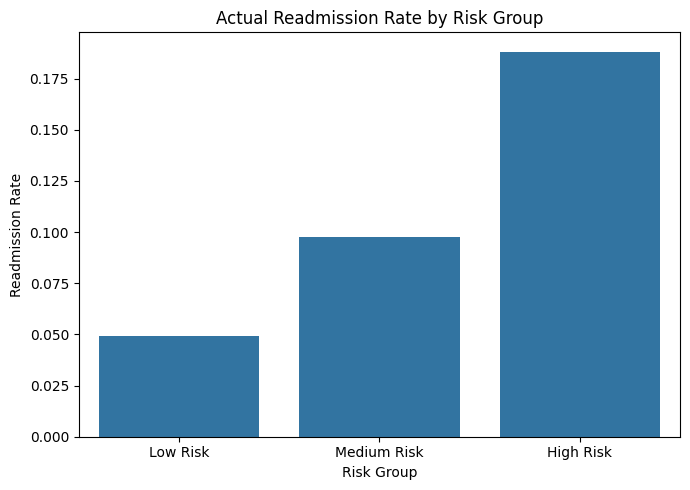

In [7]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=risk_summary,
    x="Risk Group",
    y="Actual Readmission Rate"
)

plt.title("Actual Readmission Rate by Risk Group")
plt.ylabel("Readmission Rate")
plt.tight_layout()
plt.show()

## Healthcare Recommendations

The results suggest several potential healthcare applications.

### Enhanced Discharge Planning

Patients with extensive prior inpatient utilization may benefit from enhanced discharge planning and follow-up support.

### Targeted Care Management

Risk scores generated by the model could be used to prioritize patients for care management programs.

### Post-Discharge Monitoring

Patients classified as high risk may benefit from:

- Follow-up phone calls
- Medication review
- Care coordination
- Additional outpatient monitoring

### Resource Allocation

Risk stratification may help healthcare organizations allocate limited care management resources more effectively.

## Project Limitations

Several limitations should be considered.

### Dataset Limitations

- Historical dataset
- Limited clinical variables
- Limited social determinants of health

### Modeling Limitations

- Class imbalance remains challenging
- No external validation dataset was available
- Some diagnosis code categories may contain relatively few observations

### Practical Limitations

- The model is not intended for direct clinical decision-making
- Predictions should be used as decision-support tools rather than standalone recommendations

## Future Work

Potential improvements include:

- XGBoost model development
- SMOTE-based class balancing
- Additional feature engineering
- External validation on independent datasets
- Temporal validation
- Real-time deployment architecture
- Integration into healthcare dashboards

## Final Conclusion

This project demonstrated a complete healthcare analytics workflow for predicting 30-day hospital readmissions using the UCI Diabetes dataset.

The analysis included data preparation, predictive modeling, model interpretation, model comparison, threshold tuning, and risk stratification.

Random Forest achieved the strongest overall performance and was selected as the final model. Threshold tuning demonstrated how healthcare objectives can influence classification decisions, while risk stratification showed that the model successfully separated patients into groups with progressively higher observed readmission rates.

Although the model is not intended for direct clinical use, the project illustrates how machine learning can support healthcare decision-making by identifying patients at elevated risk of readmission and enabling more targeted interventions.